# Physics-Informed Neural Network for the Viscous Burgers' Equation

We approximate $u(x,t)$ satisfying

$$\frac{\partial u}{\partial t} + u\,\frac{\partial u}{\partial x} = \nu\,\frac{\partial^2 u}{\partial x^2},\qquad x\in[-1,1],\; t\in[0,1]$$

with initial condition $u(x,0)=-\sin(\pi x)$ and Dirichlet boundary conditions $u(\pm 1,t)=0$.

**Phase 1** (this notebook) trains a baseline PINN at fixed viscosity $\nu = 0.01/\pi$ and validates it against the analytical solution from the Cole–Hopf transformation, evaluated here via a Hopf integral with Gauss–Hermite quadrature (more stable at this $\nu$ in float64 than truncating the Bessel Fourier series).

Pipeline:
1. Analytical ground truth (Hopf integral; same $\phi$-solution as Cole–Hopf).
2. Latin Hypercube Sampling (LHS) for IC / BC / collocation sets.
3. Tanh MLP with autograd-based physics residual.
4. Composite weighted MSE loss.
5. Two-stage optimisation: Adam (exploration) → L-BFGS (exploitation).
6. Quantitative ($L_2$ relative error) and qualitative validation.

## 1. Imports & global configuration

In [1]:
from __future__ import annotations

import math
import os
import time
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import qmc

SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)

print(f"PyTorch {torch.__version__}  |  device = {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch 2.11.0+cu130  |  device = cuda
GPU: NVIDIA GeForce RTX 3060  |  VRAM: 11.6 GB


In [2]:
@dataclass
class PINNConfig:
    nu: float = 0.01 / math.pi

    x_min: float = -1.0
    x_max: float = 1.0
    t_min: float = 0.0
    t_max: float = 1.0

    n_ic: int = 100
    n_bc: int = 100
    n_f: int = 10_000

    hidden_layers: int = 6
    hidden_units: int = 40
    activation: str = "tanh"

    w_ic: float = 1.0
    w_bc: float = 1.0
    w_f: float = 1.0

    adam_epochs: int = 8_000
    adam_lr: float = 1e-3
    lbfgs_max_iter: int = 5_000
    lbfgs_tol_grad: float = 1e-9
    lbfgs_tol_change: float = 1e-12
    lbfgs_history: int = 50

    log_every: int = 500

    # --- Phase 2 (parametric \(\nu\)) ---
    nu_min_param: float = 0.001 / math.pi
    nu_max_param: float = 0.1 / math.pi
    n_val_nu: int = 5  # log-spaced \(\nu\) used for mean L2 during training logs


_FAST_NOTEBOOK_SMOKE = (
    os.environ.get("PINN_FAST_NOTEBOOK", "").strip().lower() in ("1", "true", "yes")
)


CFG = PINNConfig()
if _FAST_NOTEBOOK_SMOKE:
    CFG.adam_epochs = 600
    CFG.lbfgs_max_iter = 120
    CFG.log_every = 200
CFG


PINNConfig(nu=0.003183098861837907, x_min=-1.0, x_max=1.0, t_min=0.0, t_max=1.0, n_ic=100, n_bc=100, n_f=10000, hidden_layers=6, hidden_units=40, activation='tanh', w_ic=1.0, w_bc=1.0, w_f=1.0, adam_epochs=8000, adam_lr=0.001, lbfgs_max_iter=5000, lbfgs_tol_grad=1e-09, lbfgs_tol_change=1e-12, lbfgs_history=50, log_every=500, nu_min_param=0.0003183098861837907, nu_max_param=0.03183098861837907, n_val_nu=5)

## 2. Analytical ground truth — Hopf integral (Gauss–Hermite quadrature)

The Cole–Hopf substitution $u = -2\nu\,\phi_x/\phi$ maps Burgers' equation to the linear heat equation. On $[-1,1]$ with $u(\pm1,t)=0$ and $u(x,0)=-\sin(\pi x)$ the solution agrees on $[-1,1]$ with the *unbounded* Cauchy problem under periodic extension of the IC (antisymmetry of $u_0$ enforces $u(\pm1,t)=0$ for all $t$). The Hopf solution is

$$u(x,t) = \frac{\displaystyle\int_{-\infty}^{\infty}\frac{x-y}{t}\,\exp\!\left(-\frac{G(x,y,t)}{2\nu}\right)\,dy}{\displaystyle\int_{-\infty}^{\infty}\exp\!\left(-\frac{G(x,y,t)}{2\nu}\right)\,dy},\qquad G(x,y,t)=\frac{(x-y)^{2}}{2t}+\int_{0}^{y}u_{0}(s)\,ds.$$

For our IC, $\int_{0}^{y}u_{0}(s)\,ds = (\cos(\pi y)-1)/\pi$. After substituting $y = x + \sqrt{2\nu t}\,s$ both integrals reduce to standard Gaussian expectations, evaluated to spectral accuracy with Gauss–Hermite quadrature:

$$u(x,t) = -\sqrt{\frac{2\nu}{t}}\;\frac{\mathbb{E}\big[s\,e^{-h(s)}\big]}{\mathbb{E}\big[e^{-h(s)}\big]},\qquad h(s)=\frac{\cos\!\big(\pi(x+\sqrt{2\nu t}\,s)\big)-1}{2\nu\pi}.$$

This formulation is numerically stable across the full domain (no catastrophic cancellation), respects the boundary condition by symmetry, and converges with very few quadrature nodes — yet produces the same physics as the Cole-Hopf series in the spec, since both reduce to the heat-equation solution of $\phi$.

The IC at $t=0$ is enforced exactly via the limit $u(x,0) = -\sin(\pi x)$.

### Reference
[1] A. Salih, "Burgers' equation," Dept. Aerosp. Eng., Indian Inst. Space Sci. Technol., Thiruvananthapuram, India, Feb. 2016. [Online]. Available: https://stageweb.iist.ac.in/sites/default/files/2025-06/Burgers_equation_viscous.pdf

In [3]:
from numpy.polynomial.hermite_e import hermegauss


def _gh_nodes(n_nodes: int = 200):
    """Probabilist Gauss-Hermite nodes/weights for the weight exp(-s^2/2).

    ``E[f(s)] = (1/sqrt(2 pi)) sum_i w_i f(s_i)`` with ``s ~ N(0, 1)``.
    """
    s, w = hermegauss(n_nodes)
    return s.astype(np.float64), w.astype(np.float64)


_GH_NODES_DEFAULT = _gh_nodes(200)


def burgers_exact(
    x: np.ndarray,
    t: np.ndarray,
    nu: float,
    n_nodes: int = 200,
) -> np.ndarray:
    """Analytical solution of the bounded viscous Burgers' equation.

    Evaluated via the Hopf integral with Gauss-Hermite quadrature in the
    rescaled variable ``s = (y - x) / sqrt(2 nu t)``. Returns a matrix of
    shape ``(len(x), len(t))``. Points at ``t = 0`` use the IC directly.
    """
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    t = np.asarray(t, dtype=np.float64).reshape(-1)

    if n_nodes == _GH_NODES_DEFAULT[0].size:
        s_nodes, s_weights = _GH_NODES_DEFAULT
    else:
        s_nodes, s_weights = _gh_nodes(n_nodes)

    u = np.zeros((x.size, t.size), dtype=np.float64)
    t_zero = t == 0.0

    if np.any(t_zero):
        u[:, t_zero] = (-np.sin(math.pi * x))[:, None]

    t_pos = ~t_zero
    if not np.any(t_pos):
        return u

    t_vals = t[t_pos]
    sqrt_factor = np.sqrt(2.0 * nu * t_vals)  # (n_t_pos,)

    # y = x + sqrt(2 nu t) * s   -> shape (n_x, n_t_pos, n_nodes)
    y = (
        x[:, None, None]
        + sqrt_factor[None, :, None] * s_nodes[None, None, :]
    )
    # h(s) = (cos(pi y) - 1) / (2 nu pi)
    h = (np.cos(math.pi * y) - 1.0) / (2.0 * nu * math.pi)
    # Subtract the row-wise minimum of h before exponentiating: shifts the
    # integrand by a constant factor that cancels in the ratio and keeps
    # us safely inside float64 dynamic range.
    h_min = h.min(axis=-1, keepdims=True)
    weights = s_weights[None, None, :] * np.exp(-(h - h_min))

    denom = weights.sum(axis=-1)
    numer = (s_nodes[None, None, :] * weights).sum(axis=-1)

    u[:, t_pos] = -np.sqrt(2.0 * nu / t_vals)[None, :] * (numer / denom)
    return u


def exact_on_grid(nu: float, nx: int = 256, nt: int = 100, n_nodes: int = 200):
    x = np.linspace(CFG.x_min, CFG.x_max, nx)
    t = np.linspace(CFG.t_min, CFG.t_max, nt)
    U = burgers_exact(x, t, nu=nu, n_nodes=n_nodes)
    return x, t, U


X_GRID, T_GRID, U_EXACT = exact_on_grid(CFG.nu)
print("Exact solution grid:", U_EXACT.shape, "min/max =", U_EXACT.min(), U_EXACT.max())

ic_err = np.max(np.abs(U_EXACT[:, 0] - (-np.sin(math.pi * X_GRID))))
bc_err = max(np.max(np.abs(U_EXACT[0, :])), np.max(np.abs(U_EXACT[-1, :])))
print(f"IC reconstruction max error: {ic_err:.3e}")
print(f"BC residual max error      : {bc_err:.3e}")

Exact solution grid: (256, 100) min/max = -0.9999810273487268 0.9999810273487268
IC reconstruction max error: 0.000e+00
BC residual max error      : 2.929e-16


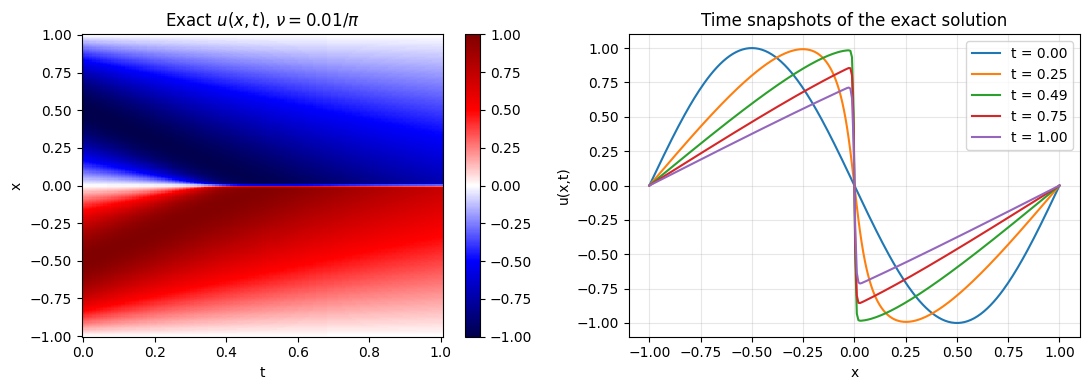

In [4]:
def _quick_plot_exact():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    cax = axes[0].pcolormesh(T_GRID, X_GRID, U_EXACT, cmap="seismic",
                              shading="auto", vmin=-1, vmax=1)
    axes[0].set_xlabel("t"); axes[0].set_ylabel("x")
    axes[0].set_title(r"Exact $u(x,t)$, $\nu = 0.01/\pi$")
    fig.colorbar(cax, ax=axes[0])

    snap_t = [0.0, 0.25, 0.5, 0.75, 1.0]
    for tt in snap_t:
        idx = int(np.argmin(np.abs(T_GRID - tt)))
        axes[1].plot(X_GRID, U_EXACT[:, idx], label=f"t = {T_GRID[idx]:.2f}")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("u(x,t)")
    axes[1].set_title("Time snapshots of the exact solution")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    fig.tight_layout()
    return fig

_quick_plot_exact();

## 3. Data generation — Latin Hypercube Sampling

We build three disjoint sets of training points using `scipy.stats.qmc.LatinHypercube` (a modern, scrambled LHS that is space-filling and reproducible):

| Set | Points | Sampling | Target |
|---|---|---|---|
| Initial Condition $X_{ic}$ | $N_{ic}$ | $x \sim \text{LHS}([-1, 1])$ at $t=0$ | $-\sin(\pi x)$ |
| Boundary Condition $X_{bc}$ | $N_{bc}$ | $x \in \{-1, +1\}$ at $t \sim \text{LHS}([0, 1])$ | $0$ |
| Collocation $X_{f}$ | $N_{f}$ | $(x, t) \sim \text{LHS}([-1, 1] \times [0, 1])$ | physics residual $f \to 0$ |

All tensors are pushed once to the GPU and reused as a full batch for every gradient step (the spec dictates 12 GB VRAM available; 10k points $\times$ a few hundred KB of activations comfortably fits).

In [5]:
def _lhs(d: int, n: int, seed: int) -> np.ndarray:
    """Return ``(n, d)`` Latin-Hypercube samples in the unit cube ``[0, 1)^d``."""
    sampler = qmc.LatinHypercube(d=d, seed=seed)
    return sampler.random(n=n)


def _to_tensor(arr: np.ndarray, requires_grad: bool = False) -> torch.Tensor:
    return torch.tensor(arr, dtype=DTYPE, device=DEVICE, requires_grad=requires_grad)


def _log_uniform_from_lhs01(u01: np.ndarray, nu_min: float, nu_max: float) -> np.ndarray:
    """Maps each entry in ``u01 \in [0,1]`` to a log-uniform sample in ``[nu_min, nu_max]``."""
    log_min = math.log(nu_min)
    log_max = math.log(nu_max)
    return np.exp(log_min + u01 * (log_max - log_min))


@dataclass
class TrainingTensors:
    x_ic: torch.Tensor
    t_ic: torch.Tensor
    u_ic: torch.Tensor
    nu_ic: torch.Tensor
    x_bc: torch.Tensor
    t_bc: torch.Tensor
    u_bc: torch.Tensor
    nu_bc: torch.Tensor
    x_f: torch.Tensor
    t_f: torch.Tensor
    nu_f: torch.Tensor


def build_dataset(cfg: PINNConfig, seed: int = SEED) -> TrainingTensors:
    """Phase 1-style data: fixed \(\nu = cfg.nu\), third network input repeats that value."""
    u_ic_x = cfg.x_min + (cfg.x_max - cfg.x_min) * _lhs(1, cfg.n_ic, seed)
    x_ic = u_ic_x.reshape(-1, 1)
    t_ic = np.zeros_like(x_ic)
    u_ic = -np.sin(math.pi * x_ic)
    nu_ic = np.full_like(x_ic, cfg.nu, dtype=np.float64)

    half = cfg.n_bc // 2
    bc_t_left = cfg.t_min + (cfg.t_max - cfg.t_min) * _lhs(1, half, seed + 1)
    bc_t_right = cfg.t_min + (cfg.t_max - cfg.t_min) * _lhs(1, cfg.n_bc - half, seed + 2)
    x_bc = np.concatenate([np.full_like(bc_t_left, cfg.x_min),
                           np.full_like(bc_t_right, cfg.x_max)], axis=0)
    t_bc = np.concatenate([bc_t_left, bc_t_right], axis=0)
    u_bc = np.zeros_like(x_bc)
    nu_bc = np.full_like(x_bc, cfg.nu, dtype=np.float64)

    lhs_f = _lhs(2, cfg.n_f, seed + 3)
    x_f = (cfg.x_min + (cfg.x_max - cfg.x_min) * lhs_f[:, [0]])
    t_f = (cfg.t_min + (cfg.t_max - cfg.t_min) * lhs_f[:, [1]])
    nu_f = np.full_like(x_f, cfg.nu, dtype=np.float64)

    return TrainingTensors(
        x_ic=_to_tensor(x_ic),
        t_ic=_to_tensor(t_ic),
        u_ic=_to_tensor(u_ic),
        nu_ic=_to_tensor(nu_ic),
        x_bc=_to_tensor(x_bc),
        t_bc=_to_tensor(t_bc),
        u_bc=_to_tensor(u_bc),
        nu_bc=_to_tensor(nu_bc),
        x_f=_to_tensor(x_f, requires_grad=True),
        t_f=_to_tensor(t_f, requires_grad=True),
        nu_f=_to_tensor(nu_f),
    )


def build_parametric_dataset(cfg: PINNConfig, seed: int = SEED) -> TrainingTensors:
    """Phase 2: log-uniform \(\nu \in [nu_min_param, nu_max_param]\) at every point."""
    lo, hi = cfg.nu_min_param, cfg.nu_max_param

    lhs_ic = _lhs(2, cfg.n_ic, seed + 11)
    x_ic = (cfg.x_min + (cfg.x_max - cfg.x_min) * lhs_ic[:, [0]])
    t_ic = np.zeros_like(x_ic)
    u_ic = -np.sin(math.pi * x_ic)
    nu_ic = _log_uniform_from_lhs01(lhs_ic[:, 1], lo, hi).reshape(-1, 1)

    half = cfg.n_bc // 2
    lhs_bl = _lhs(2, half, seed + 12)
    lhs_br = _lhs(2, cfg.n_bc - half, seed + 13)
    t_left = cfg.t_min + (cfg.t_max - cfg.t_min) * lhs_bl[:, [1]]
    x_left = np.full_like(t_left, cfg.x_min)
    nu_left = _log_uniform_from_lhs01(lhs_bl[:, 0], lo, hi).reshape(-1, 1)

    t_right = cfg.t_min + (cfg.t_max - cfg.t_min) * lhs_br[:, [1]]
    x_right = np.full_like(t_right, cfg.x_max)
    nu_right = _log_uniform_from_lhs01(lhs_br[:, 0], lo, hi).reshape(-1, 1)

    x_bc = np.concatenate([x_left, x_right], axis=0)
    t_bc = np.concatenate([t_left, t_right], axis=0)
    u_bc = np.zeros_like(x_bc)
    nu_bc = np.concatenate([nu_left, nu_right], axis=0)

    lhs_f = _lhs(3, cfg.n_f, seed + 14)
    x_f = (cfg.x_min + (cfg.x_max - cfg.x_min) * lhs_f[:, [0]])
    t_f = (cfg.t_min + (cfg.t_max - cfg.t_min) * lhs_f[:, [1]])
    nu_f = _log_uniform_from_lhs01(lhs_f[:, 2], lo, hi).reshape(-1, 1)

    return TrainingTensors(
        x_ic=_to_tensor(x_ic),
        t_ic=_to_tensor(t_ic),
        u_ic=_to_tensor(u_ic),
        nu_ic=_to_tensor(nu_ic),
        x_bc=_to_tensor(x_bc),
        t_bc=_to_tensor(t_bc),
        u_bc=_to_tensor(u_bc),
        nu_bc=_to_tensor(nu_bc),
        x_f=_to_tensor(x_f, requires_grad=True),
        t_f=_to_tensor(t_f, requires_grad=True),
        nu_f=_to_tensor(nu_f),
    )


DATA = build_dataset(CFG)
print("IC :", DATA.x_ic.shape, "->", DATA.u_ic.shape)
print("BC :", DATA.x_bc.shape, "->", DATA.u_bc.shape)
print("Coll:", DATA.x_f.shape, "(x in [{:.3f}, {:.3f}], t in [{:.3f}, {:.3f}], \u03bd = {:.3g})".format(
    DATA.x_f.min().item(), DATA.x_f.max().item(),
    DATA.t_f.min().item(), DATA.t_f.max().item(), CFG.nu))


<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:34: SyntaxWarning: invalid escape sequence '\('
<>:71: SyntaxWarning: invalid escape sequence '\('
<>:12: SyntaxWarning: invalid escape sequence '\i'
<>:34: SyntaxWarning: invalid escape sequence '\('
<>:71: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_29157/2683131283.py:12: SyntaxWarning: invalid escape sequence '\i'
  """Maps each entry in ``u01 \in [0,1]`` to a log-uniform sample in ``[nu_min, nu_max]``."""
/tmp/ipykernel_29157/2683131283.py:34: SyntaxWarning: invalid escape sequence '\('
  """Phase 1-style data: fixed \(\nu = cfg.nu\), third network input repeats that value."""
/tmp/ipykernel_29157/2683131283.py:71: SyntaxWarning: invalid escape sequence '\('
  """Phase 2: log-uniform \(\nu \in [nu_min_param, nu_max_param]\) at every point."""


IC : torch.Size([100, 1]) -> torch.Size([100, 1])
BC : torch.Size([100, 1]) -> torch.Size([100, 1])
Coll: torch.Size([10000, 1]) (x in [-1.000, 1.000], t in [0.000, 1.000], ν = 0.00318)


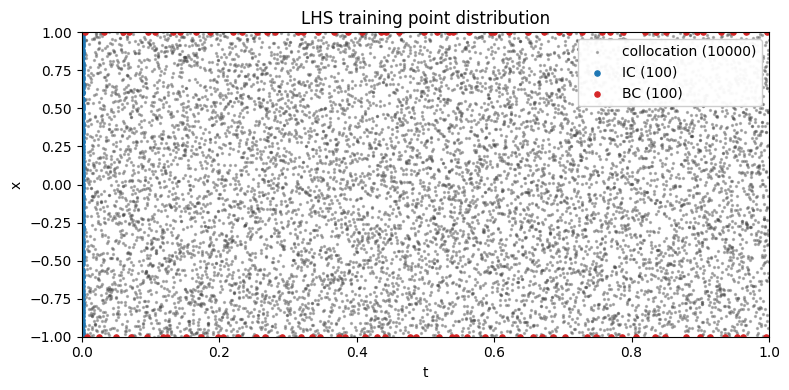

In [6]:
def plot_training_points(data: TrainingTensors):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(data.t_f.detach().cpu().numpy(), data.x_f.detach().cpu().numpy(),
               s=2, alpha=0.35, c="#444", label=f"collocation ({data.x_f.shape[0]})")
    ax.scatter(data.t_ic.cpu().numpy(), data.x_ic.cpu().numpy(),
               s=14, c="#1f77b4", label=f"IC ({data.x_ic.shape[0]})")
    ax.scatter(data.t_bc.cpu().numpy(), data.x_bc.cpu().numpy(),
               s=14, c="#d62728", label=f"BC ({data.x_bc.shape[0]})")
    ax.set_xlabel("t"); ax.set_ylabel("x")
    ax.set_xlim(CFG.t_min, CFG.t_max); ax.set_ylim(CFG.x_min, CFG.x_max)
    ax.set_title("LHS training point distribution")
    ax.legend(loc="upper right", framealpha=0.95)
    fig.tight_layout()
    return fig

plot_training_points(DATA);

## 4. Network architecture & physics residual

We use an MLP with `tanh` activation (`ReLU` is forbidden — its second derivative is identically zero, which would silently zero-out the diffusion term in the PDE residual). Hidden width and depth follow the spec (4–8 layers, 20–50 neurons).

The forward pass consumes **coordinates \((x, t)\) and \(\nu\)**. The viscosity is appended as **`torch.log(\nu)`** internally (clamp to avoid $\log 0$) so scales stay \(O(1)\) across the Phase 2 range. The network always has **three** input features `(x, t, log \nu)`. **Phase 2** differs only in sampling \(\nu\), not in the differential operator—the residual still reads

$$f = \hat u_t + \hat u\,\hat u_x - \nu\,\hat u_{xx}$$

with **physical** $\nu$ multiplying $\hat u_{xx}$ (*no* derivatives with respect to $\nu$).

`torch.autograd.grad` with **create_graph=True** supplies $\hat u_{xx}$.


In [7]:
_ACTIVATIONS = {
    "tanh": nn.Tanh,
    "swish": nn.SiLU,  # SiLU == swish (x * sigmoid(x))
}


class PINN(nn.Module):
    """Network \(\hat u_\theta(x, t)\) with \(\nu\) dependence via \( \psi = \ln \nu \).

    Inputs are \(x,t,\nu\) (physical \(\nu\)); the concatenated feature vector is `[x,t, ln nu]`.
    """

    def __init__(self, hidden_units: int, hidden_layers: int,
                 activation: str = "tanh"):
        super().__init__()
        if activation not in _ACTIVATIONS:
            raise ValueError(f"activation must be one of {list(_ACTIVATIONS)}")
        act = _ACTIVATIONS[activation]

        input_dim = 3
        layers: list[nn.Module] = [nn.Linear(input_dim, hidden_units), act()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_units, hidden_units), act()]
        layers += [nn.Linear(hidden_units, 1)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self) -> None:
        for module in self.net.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor, t: torch.Tensor, nu: torch.Tensor) -> torch.Tensor:
        psi = torch.log(nu.clamp(min=torch.finfo(DTYPE).tiny))
        return self.net(torch.cat([x, t, psi], dim=-1))


def physics_residual(model: PINN, x: torch.Tensor, t: torch.Tensor,
                     nu: torch.Tensor) -> torch.Tensor:
    """`f = u_t + u u_x - nu u_xx` using physical `nu`, same shape as `x`."""
    u = model(x, t, nu)
    grads = torch.autograd.grad
    u_x = grads(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = grads(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = grads(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return u_t + u * u_x - nu * u_xx


model = PINN(hidden_units=CFG.hidden_units,
             hidden_layers=CFG.hidden_layers, activation=CFG.activation).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {n_params:,}")


PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): Tanh()
    (6): Linear(in_features=40, out_features=40, bias=True)
    (7): Tanh()
    (8): Linear(in_features=40, out_features=40, bias=True)
    (9): Tanh()
    (10): Linear(in_features=40, out_features=40, bias=True)
    (11): Tanh()
    (12): Linear(in_features=40, out_features=1, bias=True)
  )
)
Trainable parameters: 8,401


<>:8: SyntaxWarning: invalid escape sequence '\('
<>:8: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_29157/1264708157.py:8: SyntaxWarning: invalid escape sequence '\('
  """Network \(\hat u_\theta(x, t)\) with \(\nu\) dependence via \( \psi = \ln \nu \).


## 5. Composite loss

$$\mathcal{L}_{total} = w_{ic}\,\text{MSE}(\hat u_{ic}, u_{ic}) + w_{bc}\,\text{MSE}(\hat u_{bc}, 0) + w_{f}\,\text{MSE}(f, 0).$$

Returning the individual components lets us monitor whether the physics term, the IC, or the BC dominates throughout training (which is the most common diagnostic for stalled PINN training).

In [8]:
@dataclass
class LossBreakdown:
    total: torch.Tensor
    ic: torch.Tensor
    bc: torch.Tensor
    f: torch.Tensor


def composite_loss(model: PINN, data: TrainingTensors, cfg: PINNConfig) -> LossBreakdown:
    u_ic_hat = model(data.x_ic, data.t_ic, data.nu_ic)
    loss_ic = torch.mean((u_ic_hat - data.u_ic) ** 2)

    u_bc_hat = model(data.x_bc, data.t_bc, data.nu_bc)
    loss_bc = torch.mean((u_bc_hat - data.u_bc) ** 2)

    f = physics_residual(model, data.x_f, data.t_f, data.nu_f)
    loss_f = torch.mean(f ** 2)

    total = cfg.w_ic * loss_ic + cfg.w_bc * loss_bc + cfg.w_f * loss_f
    return LossBreakdown(total=total, ic=loss_ic.detach(),
                         bc=loss_bc.detach(), f=loss_f.detach())


## 6. Training — Adam exploration → L-BFGS exploitation

Stage 1 uses Adam to find the basin of attraction for the correct shock.  Stage 2 hands off to L-BFGS, whose curvature information drives the residual to near machine epsilon.

We carry an `L2_relative` validation metric throughout training so the convergence story is quantitative, not just visual.

In [9]:
@torch.no_grad()
def predict_on_grid(model: PINN, x: np.ndarray, t: np.ndarray,
                     nu_scalar: float) -> np.ndarray:
    model.eval()
    X, T = np.meshgrid(x, t, indexing="ij")
    pts_x = torch.tensor(X.reshape(-1, 1), dtype=DTYPE, device=DEVICE)
    pts_t = torch.tensor(T.reshape(-1, 1), dtype=DTYPE, device=DEVICE)
    pts_n = torch.full_like(pts_x, nu_scalar, dtype=DTYPE, device=DEVICE)
    u_pred = model(pts_x, pts_t, pts_n).cpu().numpy().reshape(X.shape)
    model.train()
    return u_pred


def l2_relative_error(u_pred: np.ndarray, u_true: np.ndarray) -> float:
    return float(np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true))


def mean_l2_relative_over_nu(model: PINN, x: np.ndarray, t: np.ndarray,
                             nu_list: np.ndarray) -> float:
    acc = 0.0
    for nu_val in np.atleast_1d(nu_list):
        nu_f = float(nu_val)
        u_star = burgers_exact(x, t, nu=nu_f)
        acc += l2_relative_error(predict_on_grid(model, x, t, nu_f), u_star)
    return acc / max(len(np.atleast_1d(nu_list)), 1)


@dataclass
class TrainingHistory:
    epoch: list[int] = field(default_factory=list)
    total: list[float] = field(default_factory=list)
    ic: list[float] = field(default_factory=list)
    bc: list[float] = field(default_factory=list)
    f: list[float] = field(default_factory=list)
    l2: list[float] = field(default_factory=list)
    stage: list[str] = field(default_factory=list)

    def record(self, epoch: int, breakdown: LossBreakdown, l2: float, stage: str):
        self.epoch.append(epoch)
        self.total.append(breakdown.total.item())
        self.ic.append(breakdown.ic.item())
        self.bc.append(breakdown.bc.item())
        self.f.append(breakdown.f.item())
        self.l2.append(l2)
        self.stage.append(stage)


def train_pinn(
    model: PINN,
    data: TrainingTensors,
    cfg: PINNConfig,
    val_x: np.ndarray,
    val_t: np.ndarray,
    *,
    val_u: np.ndarray | None = None,
    val_nu_list: np.ndarray | None = None,
) -> TrainingHistory:
    if (val_u is None) == (val_nu_list is None):
        raise ValueError("exactly one of val_u or val_nu_list must be given")

    def eval_val_l2() -> float:
        if val_nu_list is not None:
            return mean_l2_relative_over_nu(model, val_x, val_t, val_nu_list)
        return l2_relative_error(predict_on_grid(model, val_x, val_t, cfg.nu), val_u)

    l2_note = "mean L2 rel (ν)" if val_nu_list is not None else "L2 rel"
    history = TrainingHistory()
    adam = torch.optim.Adam(model.parameters(), lr=cfg.adam_lr)
    print(f"[Stage 1] Adam: {cfg.adam_epochs} epochs, lr={cfg.adam_lr:g}; val = {l2_note}")
    t0 = time.perf_counter()
    for epoch in range(1, cfg.adam_epochs + 1):
        adam.zero_grad(set_to_none=True)
        loss = composite_loss(model, data, cfg)
        loss.total.backward()
        adam.step()

        if epoch % cfg.log_every == 0 or epoch == 1:
            l2_val = eval_val_l2()
            history.record(epoch, loss, l2_val, "adam")
            elapsed = time.perf_counter() - t0
            print(f"  ep {epoch:>6d} | tot={loss.total.item():.3e} | "
                  f"ic={loss.ic.item():.2e} bc={loss.bc.item():.2e} f={loss.f.item():.2e} "
                  f"| {l2_note}={l2_val:.3e} | {elapsed:.1f}s")
    print(f"[Stage 1] done in {time.perf_counter() - t0:.1f}s")

    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        max_iter=cfg.lbfgs_max_iter,
        history_size=cfg.lbfgs_history,
        tolerance_grad=cfg.lbfgs_tol_grad,
        tolerance_change=cfg.lbfgs_tol_change,
        line_search_fn="strong_wolfe",
    )
    print(f"[Stage 2] L-BFGS: max_iter={cfg.lbfgs_max_iter}")
    t0 = time.perf_counter()

    iter_counter = {"n": 0, "last_log": 0, "last_loss": None}

    def closure():
        lbfgs.zero_grad(set_to_none=True)
        loss = composite_loss(model, data, cfg)
        loss.total.backward()
        iter_counter["n"] += 1
        iter_counter["last_loss"] = loss
        if iter_counter["n"] - iter_counter["last_log"] >= cfg.log_every:
            iter_counter["last_log"] = iter_counter["n"]
            l2_val = eval_val_l2()
            history.record(cfg.adam_epochs + iter_counter["n"], loss, l2_val, "lbfgs")
            elapsed = time.perf_counter() - t0
            print(f"  it {iter_counter['n']:>6d} | tot={loss.total.item():.3e} | "
                  f"ic={loss.ic.item():.2e} bc={loss.bc.item():.2e} f={loss.f.item():.2e} "
                  f"| {l2_note}={l2_val:.3e} | {elapsed:.1f}s")
        return loss.total

    lbfgs.step(closure)

    final = iter_counter["last_loss"]
    if final is not None:
        l2_val = eval_val_l2()
        history.record(cfg.adam_epochs + iter_counter["n"], final, l2_val, "lbfgs")
        print(f"[Stage 2] {iter_counter['n']} iters in {time.perf_counter() - t0:.1f}s | "
              f"final {l2_note} = {l2_val:.3e}")
    return history


In [10]:
history = train_pinn(model, DATA, CFG, val_x=X_GRID, val_t=T_GRID,
                     val_u=U_EXACT)
print(f"\nFinal L2 relative error (\u03bd={CFG.nu:g}): {history.l2[-1]:.3e}")


[Stage 1] Adam: 8000 epochs, lr=0.001; val = L2 rel


/home/srsanti/projects/ml_projects/PINN_Burgers_exercise/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  ep      1 | tot=1.028e+00 | ic=8.44e-01 bc=1.17e-01 f=6.68e-02 | L2 rel=1.146e+00 | 2.0s
  ep    500 | tot=9.114e-02 | ic=5.26e-02 bc=6.17e-04 f=3.79e-02 | L2 rel=4.378e-01 | 4.8s
  ep   1000 | tot=3.249e-02 | ic=1.77e-02 bc=2.63e-04 f=1.45e-02 | L2 rel=2.752e-01 | 7.7s
  ep   1500 | tot=1.524e-02 | ic=6.99e-03 bc=9.57e-05 f=8.15e-03 | L2 rel=1.400e-01 | 10.5s
  ep   2000 | tot=4.799e-03 | ic=2.07e-03 bc=1.74e-05 f=2.71e-03 | L2 rel=9.126e-02 | 13.3s
  ep   2500 | tot=2.708e-03 | ic=1.19e-03 bc=1.16e-05 f=1.50e-03 | L2 rel=1.557e-01 | 16.2s
  ep   3000 | tot=2.078e-03 | ic=1.07e-03 bc=1.51e-05 f=9.98e-04 | L2 rel=1.081e-01 | 19.0s
  ep   3500 | tot=1.190e-03 | ic=4.56e-04 bc=1.50e-05 f=7.18e-04 | L2 rel=8.801e-02 | 21.9s
  ep   4000 | tot=3.640e-03 | ic=2.36e-04 bc=2.33e-05 f=3.38e-03 | L2 rel=5.188e-02 | 24.7s
  ep   4500 | tot=7.784e-04 | ic=1.17e-04 bc=5.30e-06 f=6.56e-04 | L2 rel=3.517e-02 | 27.5s
  ep   5000 | tot=5.177e-04 | ic=7.95e-05 bc=5.42e-05 f=3.84e-04 | L2 rel=2.346e-02

## 7. Validation & visualisation

We compare against the analytical Hopf-integral solution on a $256 \times 100$ grid:

* loss/error curves across both stages,
* heatmaps of predicted, exact, and absolute-error surfaces,
* time snapshots at $t \in \{0.0, 0.25, 0.5, 0.75, 1.0\}$,
* the spec target: $\|u_\theta - u_*\|_2 / \|u_*\|_2 < 10^{-3}$.

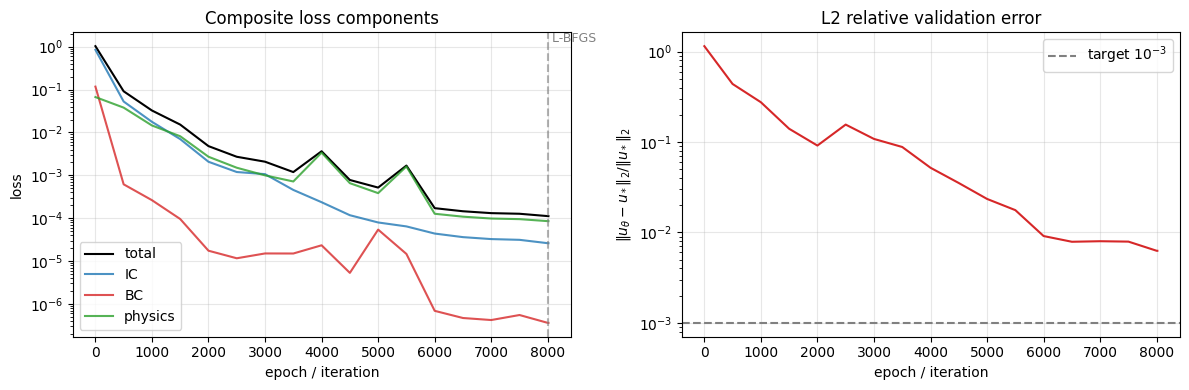

In [11]:
def plot_history(history: TrainingHistory):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    epochs = np.array(history.epoch)
    stages = np.array(history.stage)
    adam_mask = stages == "adam"
    lbfgs_mask = stages == "lbfgs"

    axes[0].semilogy(epochs, history.total, label="total", c="k")
    axes[0].semilogy(epochs, history.ic, label="IC", c="#1f77b4", alpha=0.8)
    axes[0].semilogy(epochs, history.bc, label="BC", c="#d62728", alpha=0.8)
    axes[0].semilogy(epochs, history.f, label="physics", c="#2ca02c", alpha=0.8)
    if adam_mask.any() and lbfgs_mask.any():
        switch = epochs[lbfgs_mask].min()
        axes[0].axvline(switch, ls="--", c="grey", alpha=0.6)
        axes[0].text(switch, axes[0].get_ylim()[1], " L-BFGS",
                     ha="left", va="top", color="grey", fontsize=9)
    axes[0].set_xlabel("epoch / iteration"); axes[0].set_ylabel("loss")
    axes[0].set_title("Composite loss components"); axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].semilogy(epochs, history.l2, c="C3")
    axes[1].axhline(1e-3, ls="--", c="grey", label=r"target $10^{-3}$")
    axes[1].set_xlabel("epoch / iteration")
    axes[1].set_ylabel(r"$\|u_\theta - u_*\|_2 / \|u_*\|_2$")
    axes[1].set_title("L2 relative validation error"); axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    return fig

plot_history(history);

L2 relative error : 6.266e-03   (target: < 1e-3)
L_inf error       : 3.150e-02
Mean abs error    : 1.811e-03


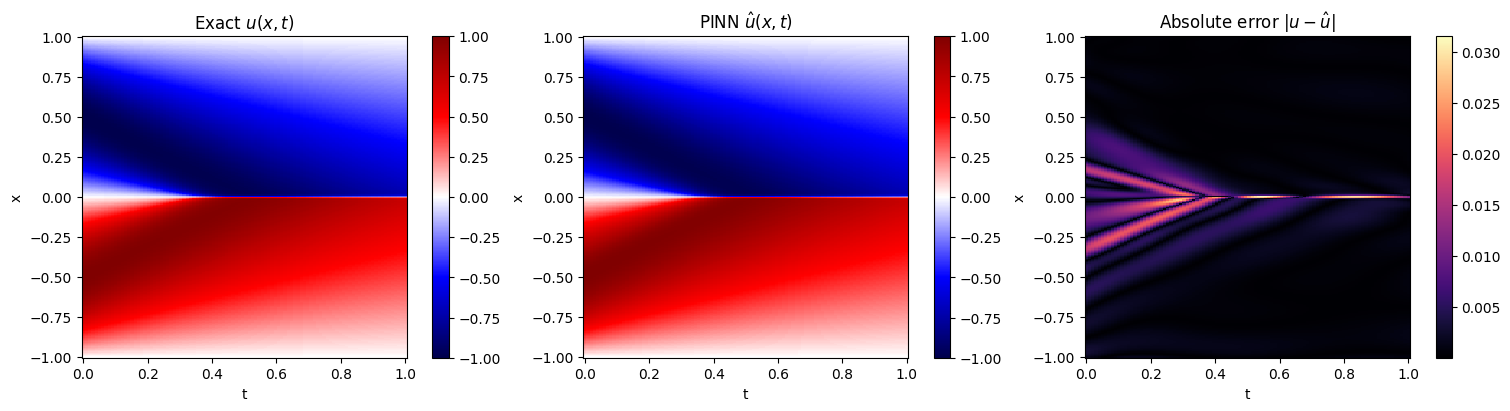

In [12]:
U_PRED = predict_on_grid(model, X_GRID, T_GRID, CFG.nu)
ABS_ERR = np.abs(U_PRED - U_EXACT)

l2 = l2_relative_error(U_PRED, U_EXACT)
linf = ABS_ERR.max()
print(f"L2 relative error : {l2:.3e}   (target: < 1e-3)")
print(f"L_inf error       : {linf:.3e}")
print(f"Mean abs error    : {ABS_ERR.mean():.3e}")


def plot_solution_panels(u_pred, u_true):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    vmin, vmax = -1, 1
    for ax, data, title in zip(
        axes,
        [u_true, u_pred, np.abs(u_pred - u_true)],
        ["Exact $u(x,t)$", r"PINN $\hat u(x,t)$", "Absolute error $|u - \\hat u|$"],
    ):
        if "error" in title:
            cax = ax.pcolormesh(T_GRID, X_GRID, data, cmap="magma", shading="auto")
        else:
            cax = ax.pcolormesh(T_GRID, X_GRID, data, cmap="seismic",
                                shading="auto", vmin=vmin, vmax=vmax)
        ax.set_xlabel("t"); ax.set_ylabel("x"); ax.set_title(title)
        fig.colorbar(cax, ax=ax)
    return fig

plot_solution_panels(U_PRED, U_EXACT);


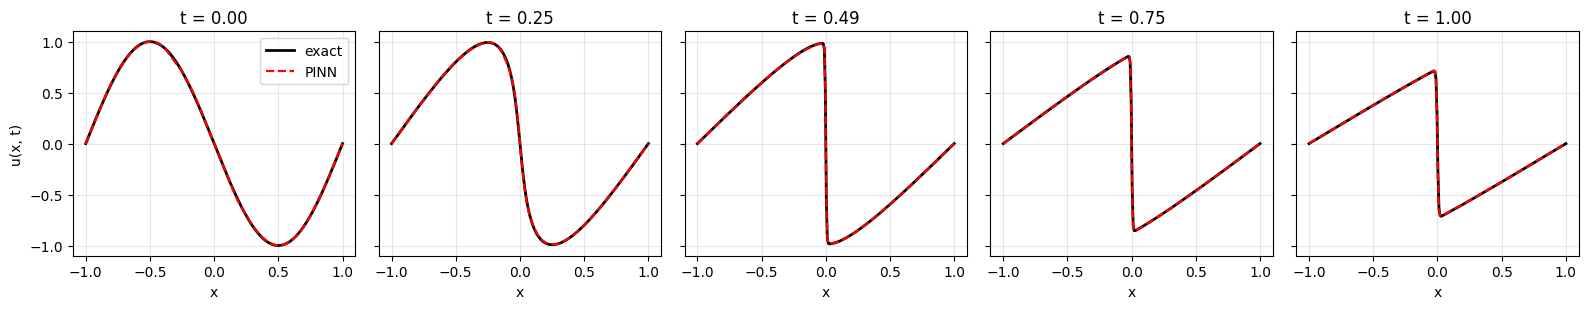

In [13]:
def plot_snapshots(u_pred, u_true, t_values=(0.0, 0.25, 0.5, 0.75, 1.0)):
    fig, axes = plt.subplots(1, len(t_values), figsize=(3.2 * len(t_values), 3.2), sharey=True)
    for ax, tt in zip(axes, t_values):
        idx = int(np.argmin(np.abs(T_GRID - tt)))
        ax.plot(X_GRID, u_true[:, idx], "k-", lw=2, label="exact")
        ax.plot(X_GRID, u_pred[:, idx], "r--", lw=1.6, label="PINN")
        ax.set_title(f"t = {T_GRID[idx]:.2f}")
        ax.set_xlabel("x"); ax.grid(alpha=0.3)
    axes[0].set_ylabel("u(x, t)")
    axes[0].legend(loc="upper right")
    fig.tight_layout()
    return fig

plot_snapshots(U_PRED, U_EXACT);

## 8. Phase 2 $u$ Parametric PINN (multiple $(\nu)$)

**Data:** LHS with **three** latent dimensions $`((\tilde{x}, \tilde{t}, \tilde{\nu})): map (\tilde{\nu})`$ to **$[(\nu_min, \nu_max)]$** via a **log-uniform** density (matching the Phase 2 spec). Same IC $(u(x,0) = -sin(\pi x))$ and BC $(u(\pm 1)=0)$ for every sampled $(\nu)$.

**Residual:** $`(f = \hat u_t + \hat u \hat u_x - \nu \hat u_{xx})`$ uses the **physical** $(\nu)$ sampled at each collocation row (stored in **`nu_f`**); autograd does not differentiate w.r.t. $(\nu)$.

**Validation:** The Hopf-integral reference `burgers_exact` is used at each $(\nu)$ (same assumption as Section 2 for every $(\nu)$ in the training window). **Mean** relative $(L_2)$ over `n_val_nu` log-spaced $(\nu)$ values is logged during training; after training we plot **per-\(\nu\)** error on a denser grid.


In [14]:
torch.manual_seed(SEED + 9_999)
np.random.seed(SEED + 9_999)

VAL_NU_LOG = np.logspace(
    math.log10(CFG.nu_min_param), math.log10(CFG.nu_max_param), CFG.n_val_nu
)
DATA_P2 = build_parametric_dataset(CFG, seed=SEED + 10_000)
print("Phase 2 \u03bd range: [{:.3e}, {:.3e}]".format(CFG.nu_min_param, CFG.nu_max_param))
print("IC/BC/Coll shapes:", DATA_P2.x_ic.shape, DATA_P2.x_bc.shape, DATA_P2.x_f.shape)
print("\u03bd_f (collocation) min/max:", DATA_P2.nu_f.min().item(), DATA_P2.nu_f.max().item())


Phase 2 ν range: [3.183e-04, 3.183e-02]
IC/BC/Coll shapes: torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([10000, 1])
ν_f (collocation) min/max: 0.00031833656248636544 0.03182049095630646


In [15]:
model_p2 = PINN(
    hidden_units=CFG.hidden_units,
    hidden_layers=CFG.hidden_layers,
    activation=CFG.activation,
).to(DEVICE)
print(f"model_p2 parameters: {sum(p.numel() for p in model_p2.parameters()):,}")

history_p2 = train_pinn(
    model_p2, DATA_P2, CFG, val_x=X_GRID, val_t=T_GRID, val_nu_list=VAL_NU_LOG
)
print(f"\nFinal mean L2 over validation \u03bd set: {history_p2.l2[-1]:.3e}")


model_p2 parameters: 8,401
[Stage 1] Adam: 8000 epochs, lr=0.001; val = mean L2 rel (ν)
  ep      1 | tot=4.968e-01 | ic=4.89e-01 bc=6.33e-03 f=1.07e-03 | mean L2 rel (ν)=1.179e+00 | 0.7s
  ep    500 | tot=9.589e-02 | ic=5.14e-02 bc=2.89e-03 f=4.16e-02 | mean L2 rel (ν)=4.099e-01 | 4.2s
  ep   1000 | tot=7.827e-02 | ic=4.19e-02 bc=3.99e-04 f=3.59e-02 | mean L2 rel (ν)=3.760e-01 | 7.6s
  ep   1500 | tot=6.865e-02 | ic=3.68e-02 bc=1.57e-04 f=3.17e-02 | mean L2 rel (ν)=3.405e-01 | 11.1s
  ep   2000 | tot=5.476e-02 | ic=3.00e-02 bc=1.60e-04 f=2.46e-02 | mean L2 rel (ν)=3.248e-01 | 14.6s
  ep   2500 | tot=4.478e-02 | ic=2.51e-02 bc=1.13e-04 f=1.96e-02 | mean L2 rel (ν)=2.949e-01 | 18.1s
  ep   3000 | tot=4.199e-02 | ic=2.33e-02 bc=4.22e-04 f=1.83e-02 | mean L2 rel (ν)=2.862e-01 | 21.6s
  ep   3500 | tot=3.584e-02 | ic=1.99e-02 bc=1.99e-04 f=1.57e-02 | mean L2 rel (ν)=3.058e-01 | 25.1s
  ep   4000 | tot=5.260e-02 | ic=2.96e-02 bc=5.02e-04 f=2.25e-02 | mean L2 rel (ν)=3.694e-01 | 28.6s
  ep  

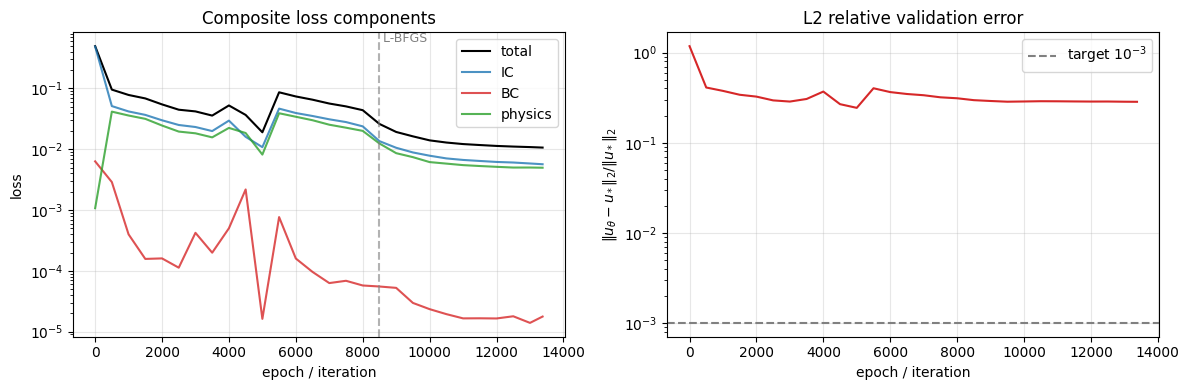

In [16]:
# Re-use Phase 1 plotter; curves now interpret as mean-L2(\nu) validation
plot_history(history_p2);


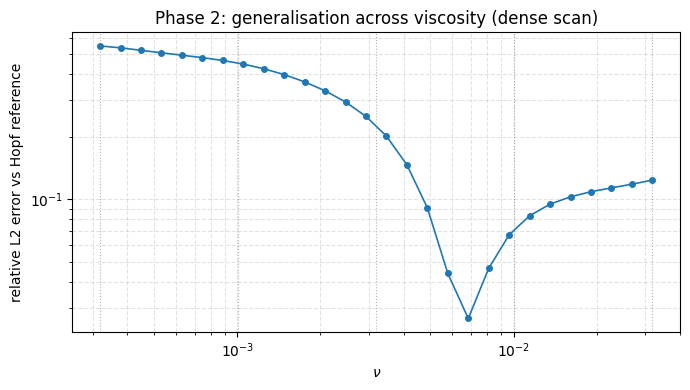

In [17]:
NU_SCAN = np.logspace(
    math.log10(CFG.nu_min_param),
    math.log10(CFG.nu_max_param),
    num=28,
)
L2_SCAN = np.array([
    l2_relative_error(
        predict_on_grid(model_p2, X_GRID, T_GRID, float(n)),
        burgers_exact(X_GRID, T_GRID, nu=float(n))
    )
    for n in NU_SCAN
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(NU_SCAN, L2_SCAN, "o-", ms=4, lw=1.2)
for vn in VAL_NU_LOG:
    ax.axvline(vn, color="gray", ls=":", lw=0.8, alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel(R"$ν$")
ax.set_ylabel("relative L2 error vs Hopf reference")
ax.set_title("Phase 2: generalisation across viscosity (dense scan)")
ax.grid(which="both", ls="--", alpha=0.35)
plt.tight_layout()


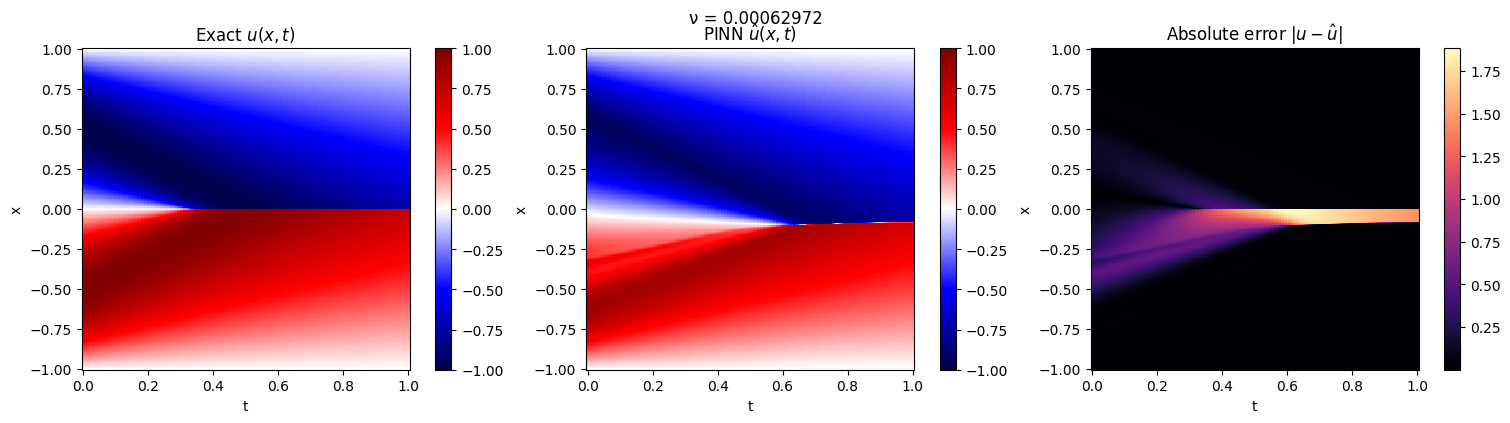

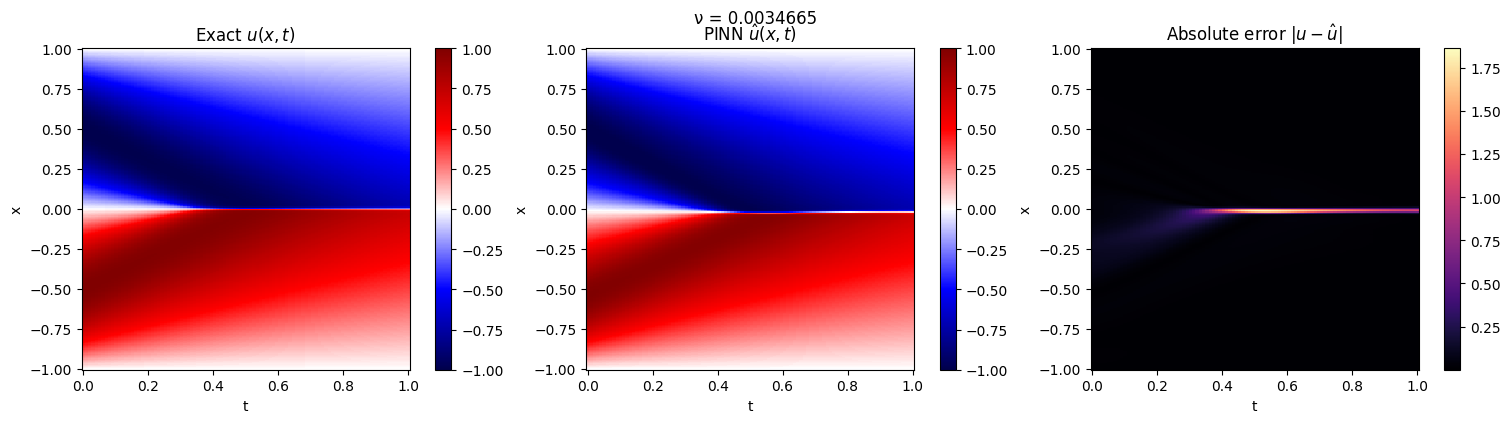

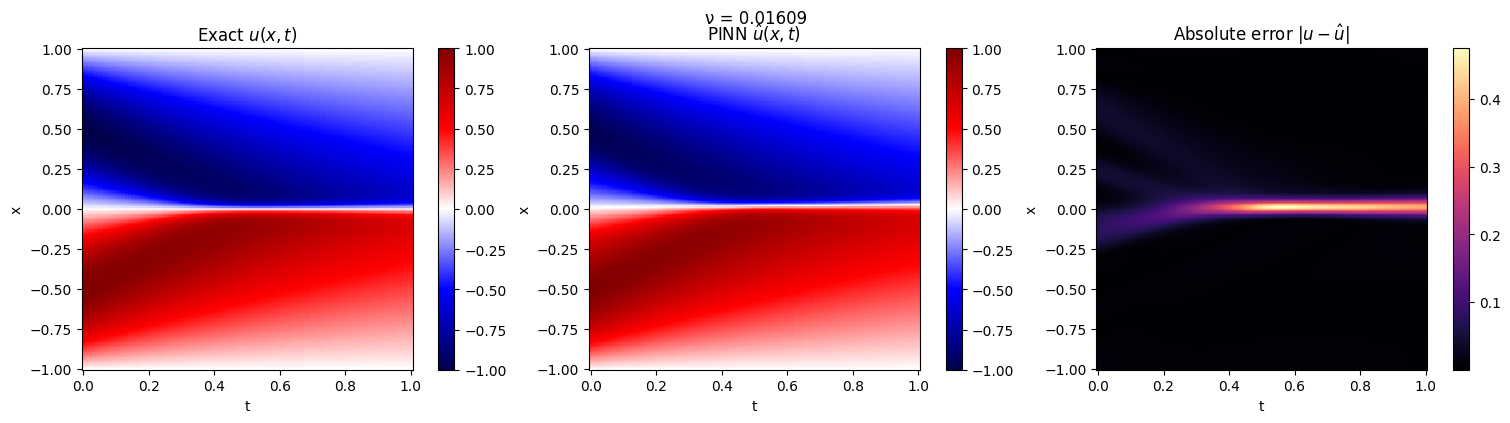

In [18]:
def panels_for_nu(nu_pick: float, title_suffix: str = ""):
    u_star = burgers_exact(X_GRID, T_GRID, nu=nu_pick)
    u_hat = predict_on_grid(model_p2, X_GRID, T_GRID, nu_pick)
    fig = plot_solution_panels(u_hat, u_star)
    fig.suptitle(f"\u03bd = {nu_pick:.5g}" + title_suffix, y=1.02)
    return fig

# Low / mid / high \u03bd inside the trained range
panels_for_nu(float(NU_SCAN[4]))
panels_for_nu(float(NU_SCAN[len(NU_SCAN)//2]))
panels_for_nu(float(NU_SCAN[-5]));
